# 7 — A real architecture, and three things wrong with it

Three modalities, three kinds of network, one head. Convolutions with
residuals, a transformer stack, a recurrent cell, and a bottleneck where they
meet — **some of it inside one node and some of it across several**, which is
the choice a graph exists to let you make.

Every section has the same four parts, and the fourth is the one the other
notebooks were missing:

1. **the problematic architecture and configuration**
2. **the symptoms**, read off what the framework measured
3. **the solution**, and why that one
4. **the healthy architecture and configuration**, run and shown to be healthy

In [1]:
import torch

import soma_next.torch  # noqa: F401
from soma_next import Graph, Node, Opaque, Recorder, Store
from soma_next.health import alerts, diagnose, overlaid, profile, seen
from soma_next.record import gantt, progress
from soma_next.torch import Audit, Trainer, architecture, parameters

torch.manual_seed(0)
store = Store(__import__("tempfile").mkdtemp())

DIM, STEPS, VOCAB, ROWS, OUT = 24, 16, 60, 64, 4

## The architecture

**Inside one node**: the convolutional trunk is a stem plus three residual
blocks, all of it `audio`'s business. Nobody outside it needs to know.

**Across nodes**: the three modalities are three nodes, because they are three
things that can be placed, cached, sent to another machine and diagnosed
apart. That is what a node is for.

In [2]:
class Residual(torch.nn.Module):
    """Norm, non-linearity, convolution, and the input added back on."""

    def __init__(self, channels, norm="batch"):
        super().__init__()
        self.norm = (
            torch.nn.BatchNorm1d(channels) if norm == "batch" else torch.nn.Identity()
        )
        self.act = torch.nn.GELU()
        self.conv = torch.nn.Conv1d(channels, channels, 3, padding=1)

    def forward(self, x):
        return x + self.conv(self.act(self.norm(x)))


class Audio(Node):
    """A convolutional trunk — a whole architecture inside one node.

    `keeps` is how the trunk turns a sequence into a vector, which is the one
    architectural decision in here that throws information away.
    """

    def __init__(self, channels=DIM, blocks=3, norm="batch", keeps="mean"):
        self.stem = torch.nn.Conv1d(1, channels, 5, padding=2)
        self.body = torch.nn.Sequential(*[Residual(channels, norm) for _ in range(blocks)])
        self.keeps = keeps

    def forward(self, said, ctx):
        h = self.body(self.stem(said["audio"]))
        if self.keeps == "mean":
            return Opaque(h.mean(-1))
        return Opaque(torch.cat([h.mean(-1), h.max(-1).values], dim=1))

    def parameters(self):
        return list(self.stem.parameters()) + list(self.body.parameters())


class Text(Node):
    """An embedding and a stack of transformer layers."""

    def __init__(self, dim=DIM, layers=4):
        self.emb = torch.nn.Embedding(VOCAB, dim)
        self.body = torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(dim, 4, 48, batch_first=True), num_layers=layers
        )

    def forward(self, said, ctx):
        return Opaque(self.body(self.emb(said["text"])).mean(1))

    def parameters(self):
        return list(self.emb.parameters()) + list(self.body.parameters())


class Vitals(Node):
    """A recurrent cell over a short series."""

    def __init__(self, dim=DIM, kind="gru"):
        self.cell = (torch.nn.GRU if kind == "gru" else torch.nn.RNN)(
            4, dim, batch_first=True
        )

    def forward(self, said, ctx):
        return Opaque(self.cell(said["vitals"])[0][:, -1])

    def parameters(self):
        return list(self.cell.parameters())


class Fuse(Node):
    """Where the three meet, through a bottleneck."""

    def __init__(self, wide=3 * DIM, squeeze=16):
        self.down = torch.nn.Linear(wide, squeeze)
        self.act = torch.nn.GELU()
        self.up = torch.nn.Linear(squeeze, OUT)

    def forward(self, said, ctx):
        return Opaque(self.up(self.act(self.down(torch.cat(list(said.values()), dim=1)))))

    def parameters(self):
        return list(self.down.parameters()) + list(self.up.parameters())


def built(*, blocks=3, layers=4, squeeze=16, keeps="mean+max"):
    wide = (2 * DIM if keeps != "mean" else DIM) + 2 * DIM
    return Graph.somatize(
        (
            Audio(blocks=blocks, keeps=keeps).named("audio")
            | Text(layers=layers).named("text")
            | Vitals().named("vitals")
        )
        >> Fuse(wide=wide, squeeze=squeeze).named("fuse")
    )

## The data

Three channels about a person and four things to predict. Two of the four are
in the **shape** of the audio — its first half against its second — and not in
its level. That distinction is the whole of Problem 1: a trunk that reduces a
sequence to its mean has thrown those two away before anything downstream ever
sees them.

In [3]:
def people(how_many=6, seed=0):
    torch.manual_seed(seed)
    made = []
    for _ in range(how_many):
        said = {
            "audio": torch.randn(ROWS, 1, 32),
            "text": torch.randint(0, VOCAB, (ROWS, STEPS)),
            "vitals": torch.randn(ROWS, STEPS, 4),
        }
        shape = said["audio"][:, 0, :16].mean(1) - said["audio"][:, 0, 16:].mean(1)
        made.append(
            (
                {one: Opaque(what) for one, what in said.items()},
                torch.stack(
                    [
                        3.0 * shape,
                        3.0 * shape.abs(),
                        0.5 * said["vitals"].mean((1, 2)),
                        0.5 * (said["text"].float().mean(1) / VOCAB),
                    ],
                    dim=1,
                ),
            )
        )
    return made


DATA = people()
ONE = DATA[0][0]


def scored(g, data=None):
    with torch.no_grad():
        data = data or DATA
        return sum(
            float(torch.nn.functional.mse_loss(g.forward(one), y)) for one, y in data
        ) / len(data)


def fit(g, run, *, steps=200, lr=3e-4, auditing=True, data=None):
    t = Trainer(
        g,
        objective=torch.nn.functional.mse_loss,
        optimizer=torch.optim.Adam(parameters(g), lr=lr),
        auditing=Audit(inside=True, every=4) if auditing else None,
        watching=Recorder(store, run=run, summarising=["loss"]),
    )
    data = data or DATA
    for which in range(steps):
        t.step(data[which % len(data)])
    return g

## What it looks like

The architecture inside each node, traced by running the graph once. A skip
connection is an **edge**, a repeated block is a `×N`, a composite everybody
recognises is one box, and the shape on every layer is what makes the
bottleneck visible.

In [4]:
healthy = built()
architecture(healthy, ONE)

{'audio': Inside(6 layers, 6 edges, traced),
 'text': Inside(2 layers, 1 edges, traced),
 'vitals': Inside(1 layers, 0 edges, traced),
 'fuse': Inside(3 layers, 2 edges, traced)}

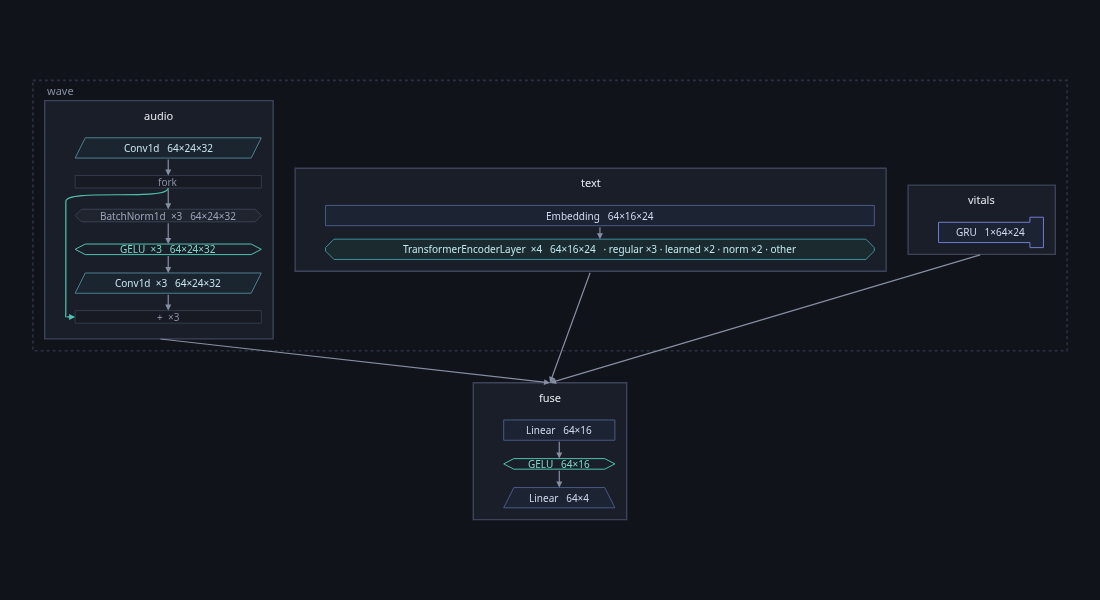

In [5]:
healthy.figure(inside=architecture(healthy, ONE))

Three branches side by side inside a wave — they run at once — and the
bottleneck at the join.

Every kind has its **own silhouette**, because a `Linear`, a convolution, a
recurrent cell and a non-linearity are four different kinds of thing and four
identical rectangles with different words in them make the reader do the
sorting a picture was supposed to have done:

| | drawn as |
|---|---|
| a convolution | a parallelogram — a window sliding along |
| a recurrent cell | a box with a tab: it feeds itself |
| an attention block | a box with its corners cut, and a line saying what is in it |
| a normalisation | a capsule: no capacity, and thin |
| a non-linearity | pointed at both ends: nothing lives in it |
| anything that **changes the width** | tapered the way it really goes |

That last one is what makes a bottleneck look like one instead of like three
boxes with different numbers written on them.

---
# Problem 1 — the join is a bottleneck

## The problematic architecture and configuration

Three branches of twenty-four each, meeting through **two** numbers.

In [6]:
pinched = built(squeeze=2)
fit(pinched, "1-problem")
print("loss :", round(scored(pinched), 4))
print("flags:", diagnose(store, run="1-problem") or "nothing tripped")

loss : 0.3579
flags: nothing tripped


## The symptoms

**No flag at all.** Every gradient arrives, nothing is dead, nothing
saturates. The network is in perfect health and it is costing about a quarter
of the loss, which is exactly the kind of thing no health check is looking
for. The diagnosis is in the picture:

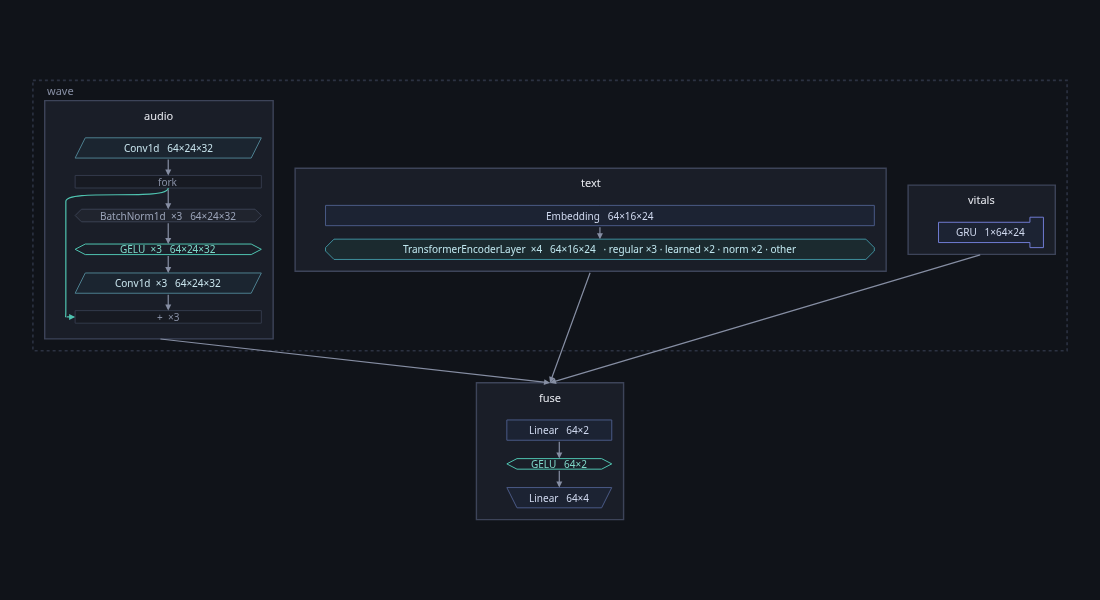

In [7]:
pinched.figure(inside=architecture(pinched, ONE))

`72 → 2 → 4`. Everything the convolutional trunk, the transformer and the
recurrent cell computed has to pass through two numbers. The shapes on the
layers are what say so, which is why they are written on the box.

## The solution

Widen the join to something the three branches can get through. Nothing else
changes — not the trunk, not the stack, not the cell.

## The healthy architecture and configuration

In [8]:
opened = built(squeeze=16)
fit(opened, "1-healthy")

print(f"squeezed to two     : {scored(pinched):.4f}")
print(f"squeezed to sixteen : {scored(opened):.4f}")
print("flags:", diagnose(store, run="1-healthy") or "nothing tripped")

squeezed to two     : 0.3575
squeezed to sixteen : 0.2761


flags: nothing tripped


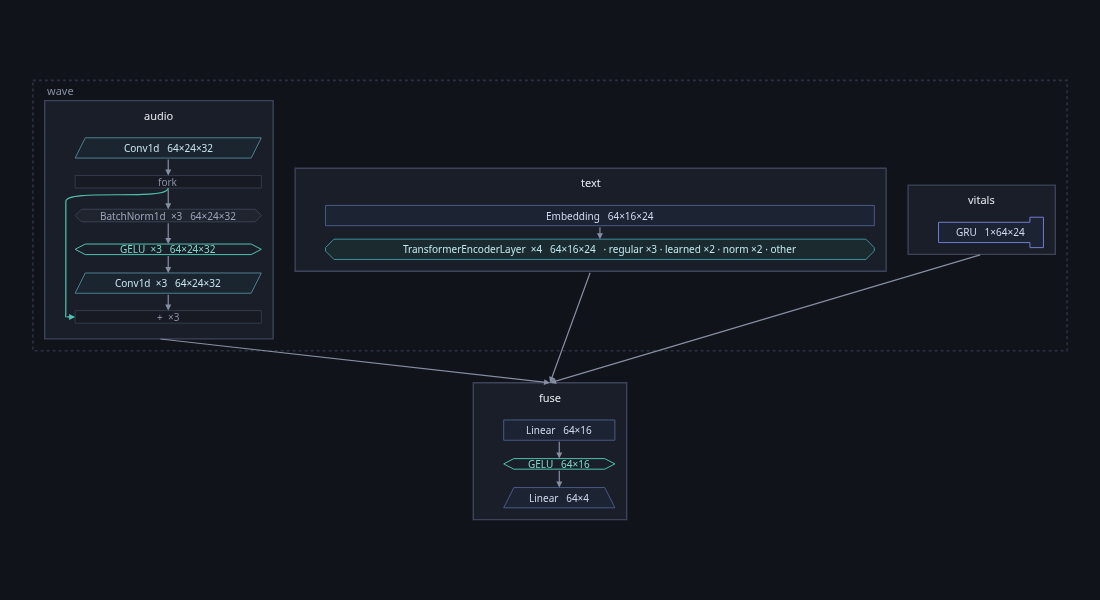

In [9]:
opened.figure(inside=architecture(opened, ONE))

---
# Problem 2 — the rate is too high

## The problematic architecture and configuration

The architecture from above, trained a thousand times faster.

In [10]:
hot = built()
fit(hot, "2-problem", lr=0.3)
print("loss:", round(scored(hot), 4))

loss: 0.4323


## The symptoms

In [11]:
alerts(store, run="2-problem")

2-problem — 35 finding(s)
  ⚠ audio: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ audio: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ audio.stem: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ audio.stem: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ audio.body.0.norm: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ audio.body.0.norm: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ audio.body.0.conv: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ audio.body.0.conv: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ audio.body.1.norm: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ audio.body.1.norm: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ audio.body.1.conv: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ audio.body.1.conv: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ audio.body.2.norm: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ audio.body.2.norm: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ audio.body.2.conv: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ audio.body.2.conv: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ text: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ text: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ text.emb: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ text.emb: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ text.body.layers.0: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ text.body.layers.0: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ text.body.layers.1: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ text.body.layers.1: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ text.body.layers.2: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ text.body.layers.2: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ text.body.layers.3: VANISHING
      this node is barely

Not one flag: a wreck, and in several places at once. **Where** is the
question a graph of four nodes actually raises, and the graph answers it:

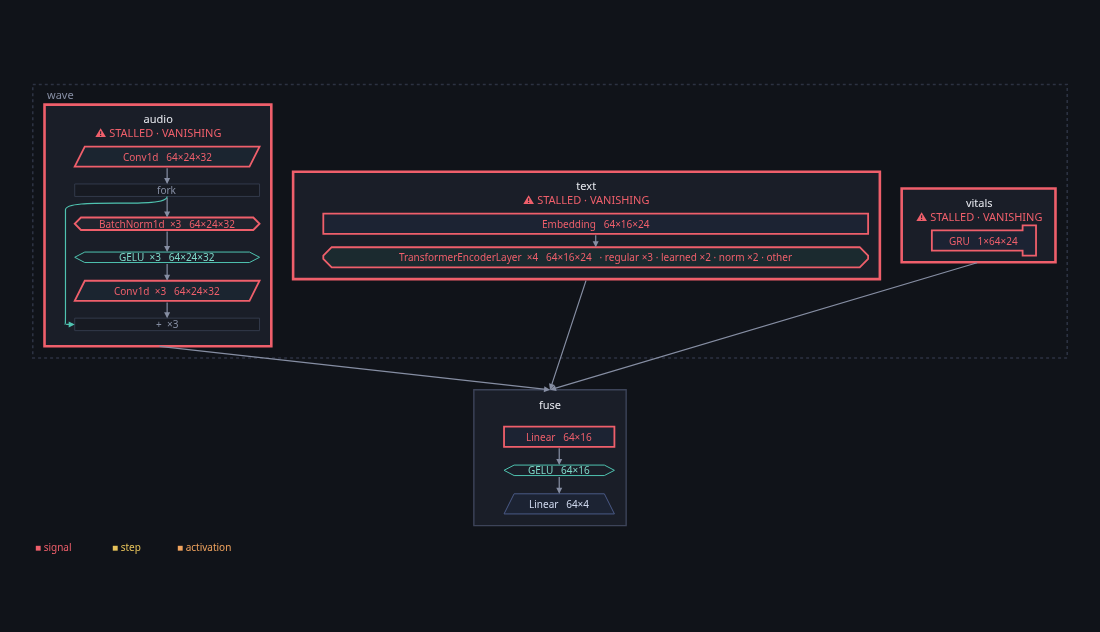

In [12]:
overlaid(hot, store, run="2-problem", inside=architecture(hot, ONE))

## The solution

The rate. What makes that a reading rather than a guess is that the same
number — the update against the weights it moves — says `STALLED` at the
other end and sits near `1e-3` when a run is healthy.

## The healthy architecture and configuration

at 0.3    : 0.4323   in 17 places


at 3e-4   : 0.2811   nothing tripped


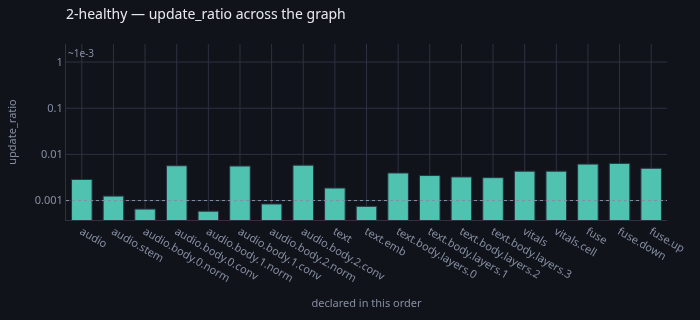

In [13]:
cooled = built()
fit(cooled, "2-healthy")

print(f"at 0.3    : {scored(hot):.4f}   in {len(diagnose(store, run='2-problem'))} places")
print(f"at 3e-4   : {scored(cooled):.4f}   {diagnose(store, run='2-healthy') or 'nothing tripped'}")
profile(store, run="2-healthy", of="update_ratio")

---
# Problem 3 — a branch nobody is using

## The problematic architecture and configuration

The healthy architecture, on the data as it stands. It trains, it is healthy,
and there are three branches in it.

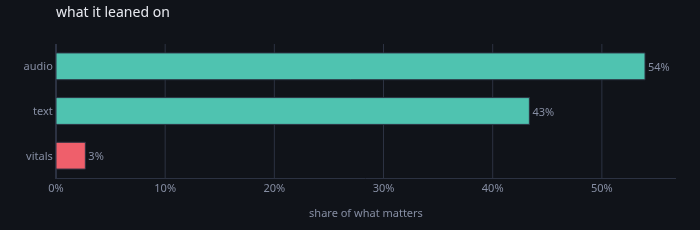

In [14]:
from soma_next.data import contribution, leaned, leaning, shares  # noqa: E402

said = contribution(cooled, DATA, objective=torch.nn.functional.mse_loss)
leaned(said)

## The symptoms

`IGNORED_INPUT(vitals)`: the recurrent branch is worth about two per cent of
what matters. It is being trained, it has no flags, and the model would score
the same if it were not there.

In [15]:
print("health:", diagnose(store, run="2-healthy") or "nothing tripped")
print("data  :", leaning(said))
print("shares:", {one: f"{share:.0%}" for one, share in shares(said).items()})

health: nothing tripped
data  : {'vitals': ['IGNORED_INPUT(vitals)']}
shares: {'audio': '54%', 'text': '43%', 'vitals': '3%'}


## The solution

**Not in the network.** There are three honest possibilities and only one of
them is code:

1. the vitals do not carry the answer — a finding about the data, and the end
   of a question rather than a bug;
2. they carry it and the cell cannot reach it — which the health checks would
   have shown, and do not;
3. another branch is a shortcut that makes the vitals unnecessary.

The first is testable in one line: put a signal in the vitals that is really
there, and see whether the same architecture picks it up.

## The healthy architecture and configuration

In [16]:
def rebalanced(how_many=6, seed=0):
    """The same data with two of the four answers genuinely in the vitals."""
    torch.manual_seed(seed)
    made = []
    for _ in range(how_many):
        said = {
            "audio": torch.randn(ROWS, 1, 32),
            "text": torch.randint(0, VOCAB, (ROWS, STEPS)),
            "vitals": torch.randn(ROWS, STEPS, 4),
        }
        shape = said["audio"][:, 0, :16].mean(1) - said["audio"][:, 0, 16:].mean(1)
        made.append(
            (
                {one: Opaque(what) for one, what in said.items()},
                torch.stack(
                    [
                        3.0 * shape,
                        3.0 * shape.abs(),
                        3.0 * said["vitals"].mean((1, 2)),
                        3.0 * said["vitals"].std((1, 2)),
                    ],
                    dim=1,
                ),
            )
        )
    return made


REAL = rebalanced()
again = built()
fit(again, "3-healthy", data=REAL)
now = contribution(again, REAL, objective=torch.nn.functional.mse_loss)

print("was:", leaning(said), {one: f"{s:.0%}" for one, s in shares(said).items()})
print("now:", leaning(now) or "nothing tripped", {one: f"{s:.0%}" for one, s in shares(now).items()})

was: {'vitals': ['IGNORED_INPUT(vitals)']} {'audio': '54%', 'text': '43%', 'vitals': '3%'}
now: nothing tripped {'audio': '78%', 'text': '5%', 'vitals': '17%'}


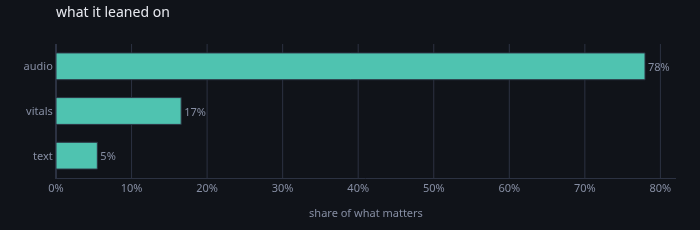

In [17]:
leaned(now)

The same architecture, the same optimizer, the same rate. What changed is the
data — and that is the answer, which no amount of looking at the network was
ever going to give.

---
## Two that did not show up

Both were tried and neither is a section above, which is worth writing down
rather than quietly replacing with an example that works.

**A plain `RNN` in place of the `GRU`**, over sixty-four steps with the answer
in the first three. It scored 0.0623 against the gated cell's 0.0592 and
raised **no flag at all** — the gradient through the plain cell was `5.2e-2`
against `6.3e-2`. Not a difference anybody should act on.

**Dropping the normalisation** from the residual trunk. The un-normalised
version scored *better* — 0.0050 against 0.0103 — and its activations grew
*less* through the stack. Three blocks is not deep enough for it to matter,
and saying it does anyway would be a lesson about somebody else's network.

A framework that always finds something has stopped being evidence. What
these two say is *at this size, on this data, it made no difference*, and
that is an answer.

## The healthy one, all together

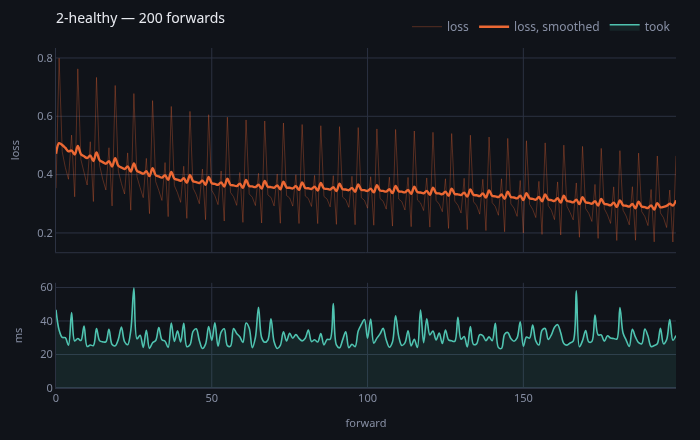

In [18]:
progress(store, run="2-healthy")

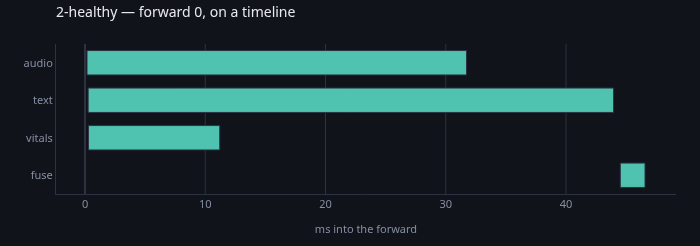

In [19]:
gantt(store, run="2-healthy", forward=0)

Three branches starting together and ending apart — that is the wave, and the
one that finishes last is the only one worth making faster.

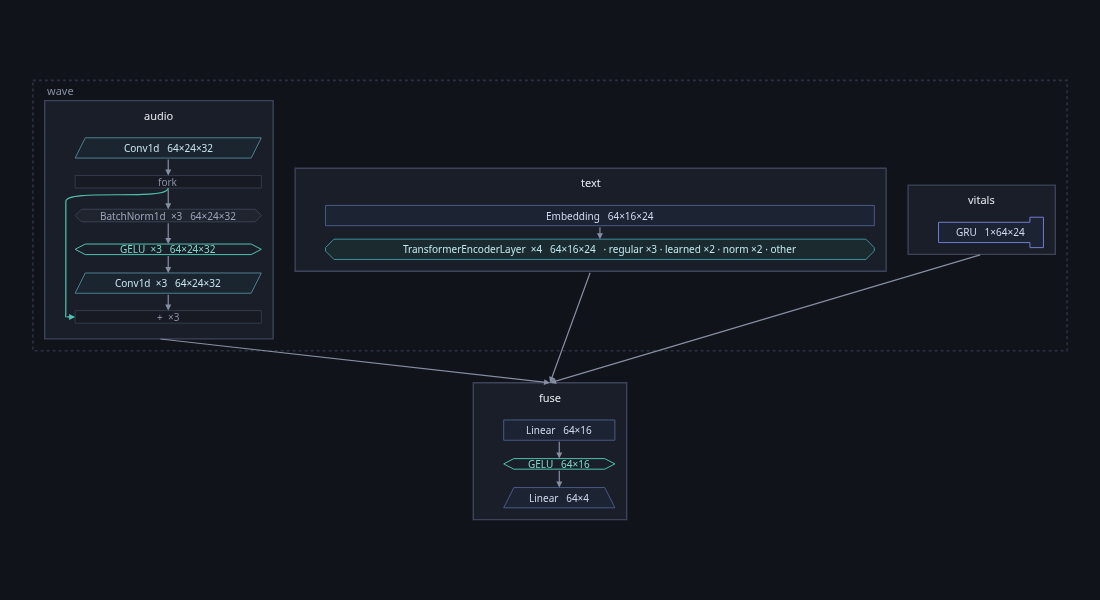

In [20]:
overlaid(cooled, store, run="2-healthy", inside=architecture(cooled, ONE))

No outline is red. That is what the end of one of these cycles looks like.